# Apparent Temperature and Heat Index: Base Aérea Daily Exposure Table

**Station:** BASE AEREA MARCO FIDEL SUAREZ (26085170), Cali
**Variables:** Temperature (T), Relative Humidity (RH)
**Objective:** Merge daily temperature and humidity data, compute physiologically meaningful heat metrics (dewpoint, apparent temperature, heat index), and produce a unified exposure table for Layer 3 heat–health analysis.
**Period:** 2015–2024 (overlap window where both T and RH data are available)
**Metrics:**
- **Dewpoint:** Absolute humidity (water vapor pressure indicator)
- **Apparent Temperature (AT):** What the air *feels like* accounting for humidity
- **Heat Index (HI):** Stress metric emphasizing nocturnal and extreme heat combined

## Section 1 — Load Daily Data and Merge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

current = Path.cwd()
while current != current.parent:
    t_daily_path = current / "shared" / "data" / "interim" / "ideam_bonilla_aragon_daily.csv"
    rh_daily_path = current / "shared" / "data" / "interim" / "ideam_bonilla_humidity_daily.csv"
    if t_daily_path.exists() and rh_daily_path.exists():
        break
    current = current.parent
else:
    raise FileNotFoundError("Daily data files not found in shared/data/interim/")

t_daily = pd.read_csv(t_daily_path, parse_dates=["fecha"])
rh_daily = pd.read_csv(rh_daily_path, parse_dates=["fecha"])

print(f"\n{'='*80}")
print("LOAD AND MERGE DAILY DATA")
print(f"{'='*80}")

print(f"\nTemperature daily table:")
print(f"  Shape: {t_daily.shape}")
print(f"  Columns: {list(t_daily.columns)}")
print(f"  Date range: {t_daily['fecha'].min()} to {t_daily['fecha'].max()}")

print(f"\nHumidity daily table:")
print(f"  Shape: {rh_daily.shape}")
print(f"  Columns: {list(rh_daily.columns)}")
print(f"  Date range: {rh_daily['fecha'].min()} to {rh_daily['fecha'].max()}")



LOAD AND MERGE DAILY DATA

Temperature daily table:
  Shape: (6596, 7)
  Columns: ['fecha', 't_max', 't_min', 't_mean', 'hourly_count', 'dayofyear', 'year']
  Date range: 2006-11-23 00:00:00 to 2024-12-13 00:00:00

Humidity daily table:
  Shape: (3635, 7)
  Columns: ['fecha', 'rh_max', 'rh_min', 'rh_mean', 'hourly_count', 'dayofyear', 'year']
  Date range: 2015-01-01 00:00:00 to 2024-12-13 00:00:00


In [2]:
# Apply quality filters independently
t_valid = t_daily[
    (t_daily['hourly_count'] >= 18) &
    (t_daily['t_min'] <= t_daily['t_max']) &
    (t_daily['t_min'] >= 10) &
    (t_daily['t_max'] <= 40)
].copy()

rh_valid = rh_daily[
    (rh_daily['hourly_count'] >= 18) &
    (rh_daily['rh_min'] > 0) &
    (rh_daily['rh_min'] <= rh_daily['rh_max']) &
    (rh_daily['rh_max'] <= 100)
].copy()

print(f"\nQuality filtering results:")
print(f"  Temperature: {len(t_valid)} of {len(t_daily)} days pass quality filter")
print(f"  Humidity: {len(rh_valid)} of {len(rh_daily)} days pass quality filter")

# Rename hourly_count to avoid collision
rh_valid = rh_valid.rename(columns={'hourly_count': 'hourly_count_rh'})
t_valid = t_valid.rename(columns={'hourly_count': 'hourly_count_t'})

# Merge on fecha (inner join — only days where both have data)
merged = pd.merge(
    t_valid[['fecha', 't_max', 't_min', 't_mean', 'hourly_count_t', 'dayofyear', 'year']],
    rh_valid[['fecha', 'rh_max', 'rh_min', 'rh_mean', 'hourly_count_rh']],
    on='fecha',
    how='inner'
)

daily_merged = merged.sort_values('fecha').reset_index(drop=True)

print(f"\nMerged exposure window:")
print(f"  Days in intersection (both valid): {len(daily_merged)}")
print(f"  Date range: {daily_merged['fecha'].min()} to {daily_merged['fecha'].max()}")
print(f"\nMerged DataFrame columns: {list(daily_merged.columns)}")



Quality filtering results:
  Temperature: 3839 of 6596 days pass quality filter
  Humidity: 1725 of 3635 days pass quality filter

Merged exposure window:
  Days in intersection (both valid): 1491
  Date range: 2015-01-01 00:00:00 to 2024-12-12 00:00:00

Merged DataFrame columns: ['fecha', 't_max', 't_min', 't_mean', 'hourly_count_t', 'dayofyear', 'year', 'rh_max', 'rh_min', 'rh_mean', 'hourly_count_rh']


## Section 2 — Load and Merge Hourly Data

In [3]:
# Load hourly temperature data (4 files)
ideam_base = Path.cwd()
while ideam_base != ideam_base.parent:
    potential = ideam_base / "shared" / "data" / "raw" / "IDEAM"
    if potential.is_dir():
        ideam_base = potential
        break
    ideam_base = ideam_base.parent
else:
    raise FileNotFoundError("IDEAM directory not found")

t_files = [
    ideam_base / "descargaDhime_2005_2010.csv",
    ideam_base / "descargaDhime_2010_2015.csv",
    ideam_base / "descargaDhime2015_2020.csv",
    ideam_base / "descargaDhime_2020_2026.csv",
]

for fpath in t_files:
    if not fpath.exists():
        raise FileNotFoundError(f"Temperature file not found: {fpath}")

print(f"\nLoading hourly temperature: {len(t_files)} files")

dfs_t = []
for fpath in t_files:
    df = pd.read_csv(fpath, parse_dates=['Fecha'], dtype={'CodigoEstacion': str, 'Valor': float})
    dfs_t.append(df)

t_hourly_raw = pd.concat(dfs_t, ignore_index=True)
t_hourly_raw = t_hourly_raw.sort_values('Fecha').reset_index(drop=True)

print(f"  Total: {len(t_hourly_raw):,} hourly records")

# Load hourly humidity data (2 files)
humidity_dir = ideam_base / "BaseAereaHumedad"
rh_files = [
    humidity_dir / "descargaDhime_BaseAerea_Humedad_2015-2020.csv",
    humidity_dir / "descargaDhime_BaseAereaHumedad_2020_2026.csv",
]

for fpath in rh_files:
    if not fpath.exists():
        raise FileNotFoundError(f"Humidity file not found: {fpath}")

print(f"Loading hourly humidity: {len(rh_files)} files")

dfs_rh = []
for fpath in rh_files:
    df = pd.read_csv(fpath, parse_dates=['Fecha'], dtype={'CodigoEstacion': str, 'Valor': float})
    dfs_rh.append(df)

rh_hourly_raw = pd.concat(dfs_rh, ignore_index=True)
rh_hourly_raw = rh_hourly_raw.sort_values('Fecha').reset_index(drop=True)

print(f"  Total: {len(rh_hourly_raw):,} hourly records")



Loading hourly temperature: 4 files
  Total: 96,774 hourly records
Loading hourly humidity: 2 files
  Total: 41,969 hourly records


In [4]:
# Standardize columns
t_hourly = t_hourly_raw[['Fecha', 'Valor']].copy()
t_hourly.columns = ['fecha', 't']
t_hourly = t_hourly.sort_values('fecha')

rh_hourly = rh_hourly_raw[['Fecha', 'Valor']].copy()
rh_hourly.columns = ['fecha', 'rh']
rh_hourly = rh_hourly.sort_values('fecha')

# Merge on fecha (inner join)
hourly_merged = pd.merge(
    t_hourly,
    rh_hourly,
    on='fecha',
    how='inner'
)

# Filter to physically valid values
hourly_merged = hourly_merged[
    (hourly_merged['t'] >= 10) &
    (hourly_merged['t'] <= 40) &
    (hourly_merged['rh'] > 0) &
    (hourly_merged['rh'] <= 100)
].copy()

hourly_merged = hourly_merged.sort_values('fecha').reset_index(drop=True)

print(f"\nHourly merge and filter:")
print(f"  Records in intersection: {len(hourly_merged):,}")
print(f"  Date range: {hourly_merged['fecha'].min()} to {hourly_merged['fecha'].max()}")



Hourly merge and filter:
  Records in intersection: 36,296
  Date range: 2015-01-01 00:00:00 to 2024-12-13 13:00:00


## Section 3 — Compute Derived Variables (Hourly)

In [5]:
# Extract hourly T and RH for clarity
t = hourly_merged['t'].values
rh = hourly_merged['rh'].values

# 1. Dewpoint from T and RH using Magnus formula (rearranged)
a, b = 17.625, 243.04
gamma = np.log(rh / 100) + (a * t) / (b + t)
dewpoint = (b * gamma) / (a - gamma)

# Sanity check: dewpoint <= T at all hours (physics constraint)
violations = (dewpoint > t).sum()
if violations > 0:
    raise ValueError(f"Dewpoint > T in {violations} records (physics violation)")

print(f"\n{'='*80}")
print("COMPUTE DERIVED VARIABLES")
print(f"{'='*80}")

print(f"\n1. Dewpoint (Magnus formula):")
print(f"   Sanity check: dewpoint <= T everywhere")
print(f"   ✓ Passed ({violations} violations)")
print(f"   Min: {dewpoint.min():.2f}°C, Max: {dewpoint.max():.2f}°C, Mean: {dewpoint.mean():.2f}°C")

# 2. Steadman apparent temperature (simplified for tropical regime, no wind)
e = (rh / 100) * 6.105 * np.exp((17.27 * t) / (237.7 + t))
at = t + 0.33 * e - 4.00

print(f"\n2. Apparent Temperature (Steadman, still air):")
print(f"   Min: {at.min():.2f}°C, Max: {at.max():.2f}°C, Mean: {at.mean():.2f}°C")

# 3. NOAA Heat Index (Rothfusz regression)
t_f = t * 9/5 + 32
hi_f = np.where(
    t_f >= 80,
    (-42.379 + 2.04901523*t_f + 10.14333127*rh
     - 0.22475541*t_f*rh - 0.00683783*t_f**2
     - 0.05481717*rh**2 + 0.00122874*t_f**2*rh
     + 0.00085282*t_f*rh**2 - 0.00000199*t_f**2*rh**2),
    t_f
)
hi = (hi_f - 32) * 5/9

print(f"\n3. Heat Index (NOAA Rothfusz, T > 26.7°C only):")
print(f"   Min: {hi.min():.2f}°C, Max: {hi.max():.2f}°C, Mean: {hi.mean():.2f}°C")

# Sanity checks
hi_valid = (hi >= t).sum()
hi_total = len(hi)
print(f"\n   Sanity check: HI >= T where defined")
print(f"   ✓ {hi_valid} of {hi_total} records pass (HI never subtracts from T)")

# Add to hourly_merged
hourly_merged['dewpoint'] = dewpoint
hourly_merged['at'] = at
hourly_merged['hi'] = hi

print(f"\nHourly table now has {len(hourly_merged.columns)} columns:")
print(f"  {list(hourly_merged.columns)}")



COMPUTE DERIVED VARIABLES

1. Dewpoint (Magnus formula):
   Sanity check: dewpoint <= T everywhere
   ✓ Passed (0 violations)
   Min: 0.56°C, Max: 32.11°C, Mean: 19.48°C

2. Apparent Temperature (Steadman, still air):
   Min: 11.30°C, Max: 46.52°C, Mean: 28.62°C

3. Heat Index (NOAA Rothfusz, T > 26.7°C only):
   Min: 13.20°C, Max: 59.71°C, Mean: 25.75°C

   Sanity check: HI >= T where defined
   ✓ 27553 of 36296 records pass (HI never subtracts from T)

Hourly table now has 6 columns:
  ['fecha', 't', 'rh', 'dewpoint', 'at', 'hi']


## Section 4 — Aggregate to Daily

In [6]:
# Set fecha as index for resampling
hourly_indexed = hourly_merged.set_index('fecha')

# Aggregate to daily using resample
daily_agg = pd.DataFrame({
    't_max': hourly_indexed['t'].resample('1D').max(),
    't_min': hourly_indexed['t'].resample('1D').min(),
    't_mean': hourly_indexed['t'].resample('1D').mean(),
    'rh_max': hourly_indexed['rh'].resample('1D').max(),
    'rh_min': hourly_indexed['rh'].resample('1D').min(),
    'rh_mean': hourly_indexed['rh'].resample('1D').mean(),
    'at_max': hourly_indexed['at'].resample('1D').max(),
    'at_min': hourly_indexed['at'].resample('1D').min(),
    'at_mean': hourly_indexed['at'].resample('1D').mean(),
    'hi_max': hourly_indexed['hi'].resample('1D').max(),
    'hi_mean': hourly_indexed['hi'].resample('1D').mean(),
    'dewpoint_max': hourly_indexed['dewpoint'].resample('1D').max(),
    'dewpoint_min': hourly_indexed['dewpoint'].resample('1D').min(),
    'dewpoint_mean': hourly_indexed['dewpoint'].resample('1D').mean(),
    'hourly_count': hourly_indexed['t'].resample('1D').count(),
})

daily_full = daily_agg.reset_index()
daily_full.columns = ['fecha'] + list(daily_agg.columns)

daily_full = daily_full[daily_full['hourly_count'] >= 18].reset_index(drop=True)

daily_full['dayofyear'] = daily_full['fecha'].dt.dayofyear
daily_full['year'] = daily_full['fecha'].dt.year

print(f"\n{'='*80}")
print("DAILY AGGREGATION")
print(f"{'='*80}")

print(f"\nTotal days with hourly_count >= 18: {len(daily_full)}")
print(f"Date range: {daily_full['fecha'].min()} to {daily_full['fecha'].max()}")
print(f"\nColumns in daily_full: {list(daily_full.columns)}")



DAILY AGGREGATION

Total days with hourly_count >= 18: 1491
Date range: 2015-01-01 00:00:00 to 2024-12-12 00:00:00

Columns in daily_full: ['fecha', 't_max', 't_min', 't_mean', 'rh_max', 'rh_min', 'rh_mean', 'at_max', 'at_min', 'at_mean', 'hi_max', 'hi_mean', 'dewpoint_max', 'dewpoint_min', 'dewpoint_mean', 'hourly_count', 'dayofyear', 'year']


## Section 5 — Sanity Plot: Diurnal Cycles

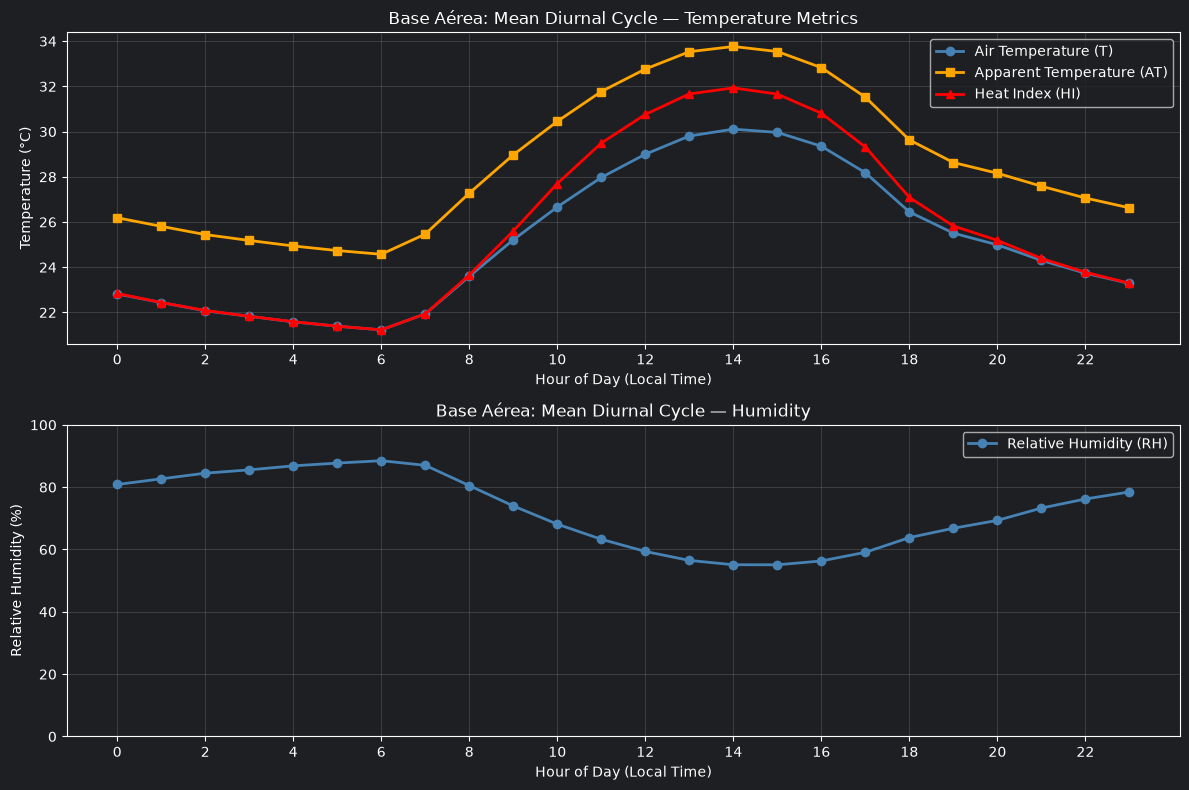


Diurnal peak hours (warmest/driest):
  Air Temperature (T): 14h
  Apparent Temperature (AT): 14h
  Heat Index (HI): 14h
  RH trough (driest): 15h


In [7]:
# Compute mean hourly values by hour of day
hourly_by_hour = hourly_merged.groupby(hourly_merged['fecha'].dt.hour).agg({
    't': 'mean',
    'rh': 'mean',
    'at': 'mean',
    'hi': 'mean',
}).reset_index()

hourly_by_hour.columns = ['hour', 't', 'rh', 'at', 'hi']

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top subplot: T, AT, HI
ax1.plot(hourly_by_hour['hour'], hourly_by_hour['t'], marker='o', linewidth=2, markersize=6, label='Air Temperature (T)', color='steelblue')
ax1.plot(hourly_by_hour['hour'], hourly_by_hour['at'], marker='s', linewidth=2, markersize=6, label='Apparent Temperature (AT)', color='orange')
ax1.plot(hourly_by_hour['hour'], hourly_by_hour['hi'], marker='^', linewidth=2, markersize=6, label='Heat Index (HI)', color='red')

ax1.set_xlabel('Hour of Day (Local Time)')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Base Aérea: Mean Diurnal Cycle — Temperature Metrics')
ax1.set_xticks(range(0, 24, 2))
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Bottom subplot: RH
ax2.plot(hourly_by_hour['hour'], hourly_by_hour['rh'], marker='o', linewidth=2, markersize=6, label='Relative Humidity (RH)', color='steelblue')

ax2.set_xlabel('Hour of Day (Local Time)')
ax2.set_ylabel('Relative Humidity (%)')
ax2.set_title('Base Aérea: Mean Diurnal Cycle — Humidity')
ax2.set_xticks(range(0, 24, 2))
ax2.set_ylim(0, 100)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report peak hours
t_peak = hourly_by_hour.loc[hourly_by_hour['t'].idxmax(), 'hour']
at_peak = hourly_by_hour.loc[hourly_by_hour['at'].idxmax(), 'hour']
hi_peak = hourly_by_hour.loc[hourly_by_hour['hi'].idxmax(), 'hour']
rh_peak = hourly_by_hour.loc[hourly_by_hour['rh'].idxmin(), 'hour']

print(f"\nDiurnal peak hours (warmest/driest):")
print(f"  Air Temperature (T): {t_peak:02.0f}h")
print(f"  Apparent Temperature (AT): {at_peak:02.0f}h")
print(f"  Heat Index (HI): {hi_peak:02.0f}h")
print(f"  RH trough (driest): {rh_peak:02.0f}h")


## Section 6 — Compare T vs AT vs HI: Distribution

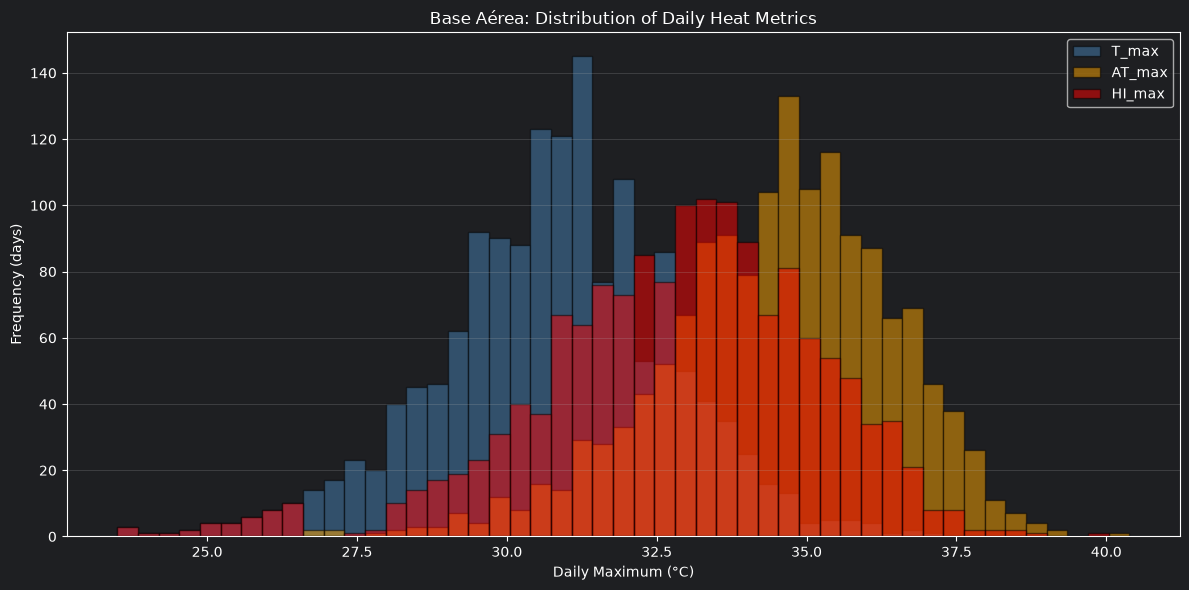


PERCENTILE COMPARISON: T_max vs AT_max vs HI_max

 Percentile  T_max    AT_max    HI_max
          5  27.30 31.093659 28.896673
         25  29.65 33.336460 31.525852
         50  30.90 34.682647 33.043066
         75  32.00 35.859758 34.423969
         95  33.90 37.416303 36.297057
         99  35.41 38.272225 37.289247

Interpretation:
  AT shifts the distribution upward compared to T, reflecting humidity's warming effect.
  HI shows a longer tail at the extreme end (95th–99th percentile),
  emphasizing that combined heat and humidity stress is worse than T alone.


In [8]:
# Plot overlaid histograms of daily maximum values
fig, ax = plt.subplots(figsize=(12, 6))

bins = np.linspace(daily_full[['t_max', 'at_max', 'hi_max']].min().min(), daily_full[['t_max', 'at_max', 'hi_max']].max().max(), 50)

ax.hist(daily_full['t_max'], bins=bins, alpha=0.5, label='T_max', color='steelblue', edgecolor='black')
ax.hist(daily_full['at_max'], bins=bins, alpha=0.5, label='AT_max', color='orange', edgecolor='black')
ax.hist(daily_full['hi_max'], bins=bins, alpha=0.5, label='HI_max', color='red', edgecolor='black')

ax.set_xlabel('Daily Maximum (°C)')
ax.set_ylabel('Frequency (days)')
ax.set_title('Base Aérea: Distribution of Daily Heat Metrics')
ax.legend(loc='best')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Percentile summary table
print(f"\n{'='*80}")
print("PERCENTILE COMPARISON: T_max vs AT_max vs HI_max")
print(f"{'='*80}")

percentiles = [5, 25, 50, 75, 95, 99]
summary = pd.DataFrame({
    'Percentile': percentiles,
    'T_max': [daily_full['t_max'].quantile(p/100) for p in percentiles],
    'AT_max': [daily_full['at_max'].quantile(p/100) for p in percentiles],
    'HI_max': [daily_full['hi_max'].quantile(p/100) for p in percentiles],
})

print(f"\n{summary.to_string(index=False)}")

print(f"\nInterpretation:")
print(f"  AT shifts the distribution upward compared to T, reflecting humidity's warming effect.")
print(f"  HI shows a longer tail at the extreme end (95th–99th percentile),")
print(f"  emphasizing that combined heat and humidity stress is worse than T alone.")


## Section 7 — Save Unified Exposure Table

In [9]:
output_dir = Path.cwd()
while output_dir != output_dir.parent:
    potential = output_dir / "shared" / "data" / "interim"
    if (potential.parent).is_dir():
        output_dir = potential
        output_dir.mkdir(exist_ok=True, parents=True)
        break
    output_dir = output_dir.parent
else:
    raise FileNotFoundError("Could not find shared/data directory")

output_path = output_dir / "ideam_bonilla_exposure_daily.csv"
daily_full.to_csv(output_path, index=False)

if not output_path.exists():
    raise FileNotFoundError(f"Output file not created: {output_path}")

print(f"\n{'='*80}")
print("SAVE UNIFIED EXPOSURE TABLE")
print(f"{'='*80}")

print(f"\nOutput path: {output_path}")
print(f"Rows: {len(daily_full):,}")
print(f"Columns: {list(daily_full.columns)}")
print(f"Date range: {daily_full['fecha'].min()} to {daily_full['fecha'].max()}")
print(f"\n✓ Unified exposure table ready for Layer 3 heat–health analysis")



SAVE UNIFIED EXPOSURE TABLE

Output path: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/ideam_bonilla_exposure_daily.csv
Rows: 1,491
Columns: ['fecha', 't_max', 't_min', 't_mean', 'rh_max', 'rh_min', 'rh_mean', 'at_max', 'at_min', 'at_mean', 'hi_max', 'hi_mean', 'dewpoint_max', 'dewpoint_min', 'dewpoint_mean', 'hourly_count', 'dayofyear', 'year']
Date range: 2015-01-01 00:00:00 to 2024-12-12 00:00:00

✓ Unified exposure table ready for Layer 3 heat–health analysis


## Section 8 — Summary

In [10]:
print(f"\n{'='*80}")
print("SUMMARY: APPARENT TEMPERATURE AND HEAT INDEX")
print(f"{'='*80}")

print(f"\nInput data sources:")
print(f"  Temperature daily records: {len(t_valid):,} (after quality filter)")
print(f"  Humidity daily records: {len(rh_valid):,} (after quality filter)")

print(f"\nMerged exposure table:")
print(f"  Days in output: {len(daily_full):,}")
print(f"  Overlap window: {daily_full['fecha'].min().date()} to {daily_full['fecha'].max().date()}")

print(f"\nCoverage by year:")
coverage_by_year = daily_full.groupby('year').size()
for year in sorted(coverage_by_year.index):
    print(f"  {year}: {coverage_by_year[year]} days")

print(f"\nDiurnal peak hours:")
print(f"  T peak: {t_peak:02.0f}h, AT peak: {at_peak:02.0f}h, HI peak: {hi_peak:02.0f}h")
print(f"  RH trough: {rh_peak:02.0f}h")

print(f"\n95th percentile heat metrics:")
print(f"  T_max: {daily_full['t_max'].quantile(0.95):.2f}°C")
print(f"  AT_max: {daily_full['at_max'].quantile(0.95):.2f}°C")
print(f"  HI_max: {daily_full['hi_max'].quantile(0.95):.2f}°C")

print(f"\nOutput CSV:")
print(f"  Path: {output_path}")
print(f"  Status: Ready for Layer 3 analysis")



SUMMARY: APPARENT TEMPERATURE AND HEAT INDEX

Input data sources:
  Temperature daily records: 3,839 (after quality filter)
  Humidity daily records: 1,725 (after quality filter)

Merged exposure table:
  Days in output: 1,491
  Overlap window: 2015-01-01 to 2024-12-12

Coverage by year:
  2015: 247 days
  2016: 259 days
  2017: 333 days
  2018: 158 days
  2019: 283 days
  2020: 83 days
  2024: 128 days

Diurnal peak hours:
  T peak: 14h, AT peak: 14h, HI peak: 14h
  RH trough: 15h

95th percentile heat metrics:
  T_max: 33.90°C
  AT_max: 37.42°C
  HI_max: 36.30°C

Output CSV:
  Path: /home/boris/PycharmProjects/CaliHeatWaves/shared/data/interim/ideam_bonilla_exposure_daily.csv
  Status: Ready for Layer 3 analysis
